# The Bingo Paradox
### Row vs Column Win Probability via Monte Carlo Simulation

This notebook explores whether rows and columns in a simplified Bingo model are truly symmetric in first-to-win probability.

We estimate probabilities empirically using Monte Carlo simulation.

## Model Assumptions

- Standard 5×5 Bingo card
- Balls 1–75 drawn without replacement
- Free center space
- Win condition: full row or full column
- Diagonals and special patterns excluded

If both occur on the same draw, the result is recorded as a tie.

## Research Question

For a single card, symmetry suggests rows and columns should be equally likely.

However, when multiple players compete and the game stops at the first win, does symmetry still hold?

In [37]:
from main import simulateGame
import matplotlib.pyplot as plt

We estimate row win probability by running repeated independent simulations.

In [38]:
def estimate_row_pct(players, runs=1000):
    results = [0, 0, 0]
    for _ in range(runs):
        results[simulateGame(players)] += 1

    row_wins, col_wins, ties = results
    return (row_wins + ties/2) / runs

In [39]:
player_counts = [1, 2, 5, 10, 20, 50, 100, 200, 500]
row_pcts = [estimate_row_pct(p, runs=5000) for p in player_counts]

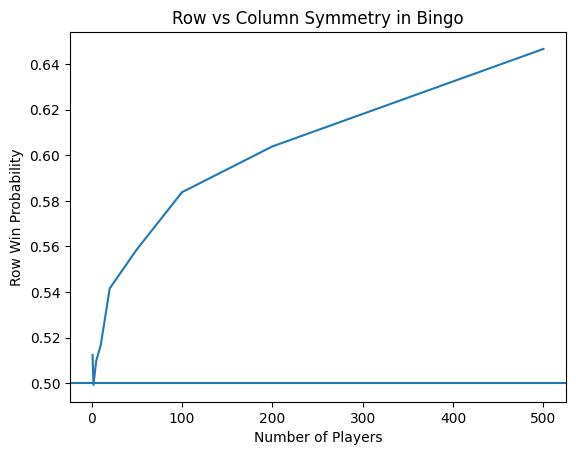

In [40]:
plt.figure()
plt.plot(player_counts, row_pcts)
plt.axhline(0.5)
plt.xlabel("Number of Players")
plt.ylabel("Row Win Probability")
plt.title("Row vs Column Symmetry in Bingo")
plt.show()

## Observations

- For 1 player, row and column wins are approximately symmetric.
- As the number of players increases, row win probability increases.
- The game ending at the first win amplifies subtle structural asymmetries.

This suggests that symmetry at the single-card level does not guarantee symmetry in competitive first-to-win settings.

## Conclusion

Monte Carlo simulation suggests that while rows and columns are symmetric for a single card, increasing the number of players produces a consistent shift in first-to-win outcomes.

Although each card is individually symmetric, stopping the game at the first win across many players changes the overall probability balance.